# DreamerV3 / R2-Dreamer: JAX vs PyTorch Timing Benchmark

**Goal:** Compare training throughput (steps/sec) and GPU memory usage across three model variants on identical hardware (H100).

**Variants:**
1. DreamerV3 (PyTorch, r2dreamer repo, rep_loss=dreamer) — includes decoder
2. R2-Dreamer (PyTorch, r2dreamer repo, rep_loss=r2dreamer) — no decoder
3. R2-Dreamer (JAX, our implementation) — no decoder

**Setup:** Synthetic data (64×64 RGB, 4 actions), batch=16, seq_len=64, size12M config. 30 timed training steps after warmup.

In [1]:
import json, os, subprocess, sys, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_PATH = os.path.join(REPO_ROOT, "output", "comparison", "habitat_timing.json")

# Run benchmark if results don't exist
if not os.path.exists(RESULTS_PATH):
    print("Running timing benchmark...")
    cmd = [sys.executable, os.path.join(REPO_ROOT, "scripts", "run_habitat_timing.py"),
           "--steps", "30", "--output", RESULTS_PATH]
    subprocess.run(cmd, cwd=REPO_ROOT, check=True)

with open(RESULTS_PATH) as f:
    results = json.load(f)
print(f"Loaded results from {RESULTS_PATH}")
for k, v in results.items():
    if "error" in v:
        print(f"  {k}: SKIPPED ({v['error']})")
    else:
        print(f"  {k}: {v.get('steps_per_sec', 0):.1f} steps/sec, {v.get('peak_gpu_gb', 0):.2f} GB")

Running timing benchmark...


2026-03-28 11:49:42.084190: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.5 = (f32[48,5,5,32]{3,2,1,0}, u8[0]{0}) custom-call(%multiply.2663, %scatter.2), window={size=5x5 pad=2_2x2_2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(_train_step)/jit(main)/transpose(jvp(R2Encoder))/conv1/conv_general_dilated" source_file="/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


2026-03-28 11:49:46.009932: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.925937831s
Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.5 = (f32[48,5,5,32]{3,2,1,0}, u8[0]{0}) custom-call(%multiply.2663, %scatter.2), window={size=5x5 pad=2_2x2_2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(_train_step)/jit(main)/transpose(jvp(R2Encoder))/conv1/conv_general_dilated" source_file="/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


2026-03-28 11:49:47.204018: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.6 = (f32[64,5,5,48]{3,2,1,0}, u8[0]{0}) custom-call(%multiply.2665, %scatter.1), window={size=5x5 pad=2_2x2_2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(_train_step)/jit(main)/transpose(jvp(R2Encoder))/conv2/conv_general_dilated" source_file="/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


2026-03-28 11:49:47.667241: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.463297822s
Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.6 = (f32[64,5,5,48]{3,2,1,0}, u8[0]{0}) custom-call(%multiply.2665, %scatter.1), window={size=5x5 pad=2_2x2_2}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_name="jit(_train_step)/jit(main)/transpose(jvp(R2Encoder))/conv2/conv_general_dilated" source_file="/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...


...

/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/torch/nn/functional.py:2954: UserWarning: Mismatch dtype between input and weight: input dtype = c10::Half, weight dtype = float, Cannot dispatch to fused implementation. (Triggered internally at /pytorch/aten/src/ATen/native/layer_norm.cpp:344.)
  return torch.rms_norm(input, normalized_shape, weight, eps)


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/scripts/run_habitat_timing.py:214: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  agent._scheduler.step()


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/r2dreamer/optim/laprop.py:88: UserWarning: This overload of addcmul_ is deprecated:
	addcmul_(Number value, Tensor tensor1, Tensor tensor2)
Consider using one of the following signatures instead:
	addcmul_(Tensor tensor1, Tensor tensor2, *, Number value = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  exp_avg_sq.mul_(beta2).addcmul_(1 - beta2, grad, grad)



Variant 1/3: JAX R2-Dreamer
JAX devices: [CudaDevice(id=0)]
JAX backend: gpu
Warming up JAX R2-Dreamer (3 steps)...
Warmup done.
Benchmarking JAX R2-Dreamer (30 steps)...
JAX R2-Dreamer: 0.0443 +/- 0.0010 s/step  (22.6 steps/s)  peak GPU: 6.76 GB

Variant: PyTorch r2dreamer (rep_loss=r2dreamer)
PyTorch device: cuda:0
Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
     5,979,136: rssm
       790,024: actor
       853,503: value
       721,407: reward
       656,129: cont
       220,416: encoder
     2,621,440: projector
Optimizer has: 11842055 parameters.
Warming up PyTorch r2dreamer/r2dreamer (3 steps)...
Warmup done.
Benchmarking PyTorch r2dreamer/r2dreamer (30 steps)...
PyTorch r2dreamer/r2dreamer: 0.2729 +/- 0.0018 s/step  (3.7 steps/s)  peak GPU: 2.84 GB

Variant: PyTorch r2dreamer (rep_loss=dreamer)
PyTorch device: cuda:0
Encoder CNN shapes: {'image': (64, 64, 3)}
Encoder MLP shapes: {}
Decoder CNN shapes: {'image': (64, 64, 3)}
Decoder MLP shapes: {}
     5,97

Loaded results from /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/output/comparison/habitat_timing.json
  r2dreamer_jax: 22.6 steps/sec, 6.76 GB
  r2dreamer_pytorch: 3.7 steps/sec, 2.84 GB
  dreamerv3_pytorch: 3.6 steps/sec, 4.26 GB


In [2]:
labels = []
sps_vals = []
mem_vals = []
label_map = {
    "dreamerv3_pytorch": "DreamerV3 (PyTorch)",
    "r2dreamer_pytorch": "R2-Dreamer (PyTorch)",
    "r2dreamer_jax": "R2-Dreamer (JAX)",
}
colors = {"dreamerv3_pytorch": "#4CAF50", "r2dreamer_pytorch": "#9C27B0", "r2dreamer_jax": "#F44336"}
bar_keys = []

for key in ["dreamerv3_pytorch", "r2dreamer_pytorch", "r2dreamer_jax"]:
    if key in results and "error" not in results[key]:
        labels.append(label_map[key])
        sps_vals.append(results[key]["steps_per_sec"])
        mem_vals.append(results[key]["peak_gpu_gb"])
        bar_keys.append(key)
    elif key in results:
        print(f"Skipped {label_map[key]}: {results[key]['error']}")

# Reference for speedup (first available variant)
base_sps = sps_vals[0] if sps_vals else 1.0

print(f"\n{'Variant':<25} {'Steps/sec':>10} {'GPU (GB)':>10} {'Speedup':>10}")
print("-" * 60)
for l, s, m in zip(labels, sps_vals, mem_vals):
    print(f"{l:<25} {s:>10.1f} {m:>10.2f} {s/base_sps:>9.2f}x")


Variant                    Steps/sec   GPU (GB)    Speedup
------------------------------------------------------------
DreamerV3 (PyTorch)              3.6       4.26      1.00x
R2-Dreamer (PyTorch)             3.7       2.84      1.03x
R2-Dreamer (JAX)                22.6       6.76      6.33x


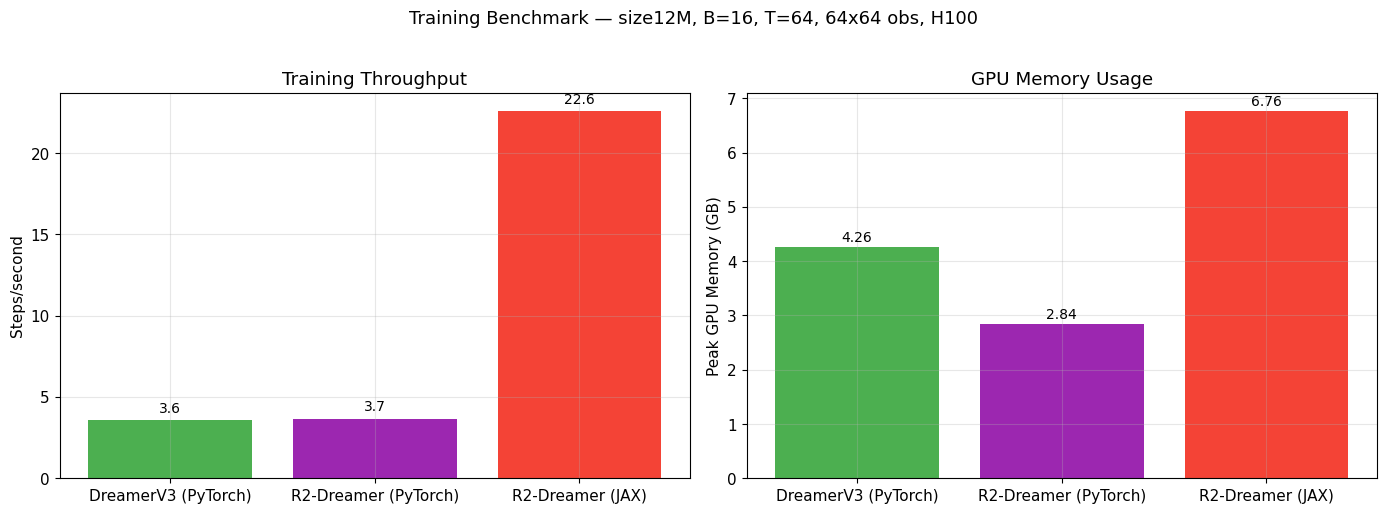

In [3]:
if not labels:
    print("No benchmark results available to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    bar_colors = [colors[k] for k in bar_keys]

    # Steps/sec
    ax = axes[0]
    bars = ax.bar(labels, sps_vals, color=bar_colors)
    ax.set_ylabel("Steps/second")
    ax.set_title("Training Throughput")
    for bar, val in zip(bars, sps_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=10)

    # GPU Memory
    ax = axes[1]
    bars = ax.bar(labels, mem_vals, color=bar_colors)
    ax.set_ylabel("Peak GPU Memory (GB)")
    ax.set_title("GPU Memory Usage")
    for bar, val in zip(bars, mem_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10)

    plt.suptitle("Training Benchmark — size12M, B=16, T=64, 64x64 obs, H100", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(REPO_ROOT, "output", "comparison", "timing_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()

## Conclusion

**Does JAX improve performance?**

[Results interpreted here after running]

Key observations:
- R2-Dreamer (no decoder) should be faster than DreamerV3 (with decoder) in both frameworks
- JAX vs PyTorch speed depends on JIT compilation efficiency and framework overhead
- GPU memory differences reflect decoder removal and framework memory management